# Colorization pretext task

Self supervised pretraining of the food classifier encoder using image colorization as the pretext task. The encoder is trained to predict color from a grayscale version of the same image, without ever using the class labels. Once pretraining is done the encoder is frozen and used as a feature extractor, and a traditional classifier is trained on top of the extracted features.

Same data pipeline, same dataset split and same encoder depth as the medium net supervised experiment, so the two runs can be compared fairly.

## Installing extra packages

Lightning for the training loop, scikit image for the RGB to Lab color conversion used by the colorization task.

In [ ]:
!pip install -q lightning scikit-image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 59.8 MB/s eta 0:00:00


In [ ]:
import os
import zipfile
import numpy as np
from skimage.color import rgb2lab, lab2rgb
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
import torch
import torch.nn as nn
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import CSVLogger
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import json

## Downloading and extracting the dataset

Same as the other experiment notebooks. Colab local disk is wiped every session so this has to run again each time. The Kaggle credentials are read from Colab secrets instead of being written directly in the notebook, so nothing sensitive ends up saved in the file itself.

In [ ]:
os.environ['KAGGLE_API_TOKEN'] = 'your_token'

!pip install -q kaggle
!kaggle competitions download -c ifood-2019-fgvc6 -p /content/ifood_raw

100% 2.84G/2.84G [00:21<00:00, 139MB/s]



In [ ]:
extract_path = "/content/ifood/"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile("/content/ifood_raw/ifood-2019-fgvc6.zip", "r") as zf:
    zf.extractall(extract_path)

!ls -la {extract_path}

total 2993536
drwxr-xr-x 2 root root       4096 Aug 15 20:37 .
drwxr-xr-x 1 root root       4096 Aug 15 20:36 ..
-rw-r--r-- 1 root root       3717 Aug 15 20:36 class_list.txt
-rw-r--r-- 1 root root     567555 Aug 15 20:36 ifood2019_sample_submission.csv
-rw-r--r-- 1 root root     567555 Aug 15 20:36 sample_submission.csv
-rw-r--r-- 1 root root  551912960 Aug 15 20:36 test_set.zip
-rw-r--r-- 1 root root    2435315 Aug 15 20:36 train_labels.csv
-rw-r--r-- 1 root root 2277605678 Aug 15 20:37 train_set.zip
-rw-r--r-- 1 root root     222409 Aug 15 20:37 val_labels.csv
-rw-r--r-- 1 root root  232027129 Aug 15 20:37 val_set.zip


In [ ]:
for zip_name in ["train_set.zip", "val_set.zip"]:
    print("Extracting", zip_name)
    with zipfile.ZipFile(f"/content/ifood/{zip_name}", "r") as zf:
        zf.extractall("/content/ifood/")

!ls -la /content/ifood/

Extracting train_set.zip
Extracting val_set.zip
total 2998108
drwxr-xr-x 4 root root       4096 Aug 15 20:37 .
drwxr-xr-x 1 root root       4096 Aug 15 20:36 ..
-rw-r--r-- 1 root root       3717 Aug 15 20:36 class_list.txt
-rw-r--r-- 1 root root     567555 Aug 15 20:36 ifood2019_sample_submission.csv
-rw-r--r-- 1 root root     567555 Aug 15 20:36 sample_submission.csv
-rw-r--r-- 1 root root  551912960 Aug 15 20:36 test_set.zip
-rw-r--r-- 1 root root    2435315 Aug 15 20:36 train_labels.csv
drwxr-xr-x 2 root root    4222976 Aug 15 20:37 train_set
-rw-r--r-- 1 root root 2277605678 Aug 15 20:37 train_set.zip
-rw-r--r-- 1 root root     222409 Aug 15 20:37 val_labels.csv
drwxr-xr-x 2 root root     446464 Aug 15 20:37 val_set
-rw-r--r-- 1 root root  232027129 Aug 15 20:37 val_set.zip


## Loading the shared utilities

food_utils.ipynb gives us FoodDataModule for the train and validation split, count_parameters and evaluate for later. We do not use FoodDataset or FoodClassifier here since the pretext task needs its own data format and its own training loop, both defined below.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

# path Angy
#PROJECT_DIR = "/content/drive/MyDrive/food-project"
# path K
PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks/food-project"

UTILS_PATH = os.path.join(PROJECT_DIR, "food_utils.ipynb")

%run "{UTILS_PATH}"

Mounted at /content/drive


## Experiment configuration

Same img_size, batch_size and cap as the medium net supervised run, so
the two experiments see the same images. lr and weight_decay are for
the colorization pretraining stage only. The linear probe trained later
on the extracted features uses scikit-learn's LogisticRegression with
its default solver, so there's no learning rate to configure for that
stage.

In [ ]:
CFG = {
    "data_dir": "/content/ifood",
    "img_size": 224,
    "batch_size": 64,
    "max_epochs": 100,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "val_frac": 0.15,
    "cap": 500,
    "num_workers": 2,
    "num_classes": 251,
}

for key, value in CFG.items():
    print(key, ":", value)

data_dir : /content/ifood
img_size : 224
batch_size : 64
max_epochs : 100
lr : 0.001
weight_decay : 0.0001
val_frac : 0.15
cap : 500
num_workers : 2
num_classes : 251


## Setting up the data module

We reuse FoodDataModule exactly as in the supervised experiments, same cap and same stratified split. During pretraining we only look at the path column of train_df and val_df, the label column is ignored completely. Keeping the same split as the supervised run matters, it means the encoder never sees during pretraining any image that ends up in the validation set used later to report results.

In [ ]:
dm = FoodDataModule(
    data_dir=CFG["data_dir"],
    img_size=CFG["img_size"],
    batch_size=CFG["batch_size"],
    val_frac=CFG["val_frac"],
    cap=CFG["cap"],
    num_workers=CFG["num_workers"],
)
dm.setup()

train images: 96326
val images: 16999
test images: 11994


## From RGB to Lab

Colorization needs a way to split an image into a grayscale part, the input, and a color part, the target to predict. Instead of doing this in plain RGB we convert every image to the Lab color space. The L channel carries lightness only, no color information, and becomes the input to the encoder. The a and b channels carry the color information and become the target the decoder has to predict.

The reason to prefer Lab over RGB here is that in RGB the grey value of a pixel is entangled with all three channels together, there is no single RGB channel that is exactly equivalent to a grayscale image. In Lab the split is clean and exact, L alone already is the grayscale version of the picture.

L is rescaled from its native 0 to 100 range down to 0 to 1. The a and b channels are rescaled from their native range, roughly minus 128 to 127, down to about minus 1 to 1, which keeps the regression target in a small and well behaved range for the network to predict.

In [ ]:
def image_to_lab_tensors(img_pil):
    img_np = np.array(img_pil).astype(np.float32) / 255.0
    lab = rgb2lab(img_np)

    L = lab[:, :, 0] / 100.0
    ab = lab[:, :, 1:] / 128.0

    L_tensor = torch.from_numpy(L).unsqueeze(0).float()
    ab_tensor = torch.from_numpy(ab).permute(2, 0, 1).float()
    return L_tensor, ab_tensor


def lab_tensors_to_rgb(L_tensor, ab_tensor):
    L = L_tensor * 100.0
    ab = ab_tensor * 128.0
    lab = torch.cat([L, ab], dim=0).permute(1, 2, 0).cpu().numpy()
    rgb = lab2rgb(lab)
    return np.clip(rgb, 0, 1)

## Dataset for the pretext task

Only the image path is used, the label column of the dataframe is never read. A light spatial augmentation, random crop and horizontal flip, is applied on the RGB image before the Lab conversion. No color augmentation of any kind is applied, changing brightness or saturation would change the actual target the decoder has to predict, which would break the task.

In [ ]:
def get_spatial_transform(split, img_size=224):
    if split == "train":
        return T.Compose([
            T.Resize(int(img_size * 1.15)),
            T.RandomCrop(img_size),
            T.RandomHorizontalFlip(p=0.5),
        ])
    else:
        return T.Compose([
            T.Resize(int(img_size * 1.15)),
            T.CenterCrop(img_size),
        ])


class ColorizationDataset(Dataset):
    def __init__(self, df, split, img_size=224):
        self.df = df.reset_index(drop=True)
        self.transform = get_spatial_transform(split, img_size)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row["path"]).convert("RGB")
        except (OSError, IOError):
            return self.__getitem__((idx + 1) % len(self.df))

        img = self.transform(img)
        L, ab = image_to_lab_tensors(img)
        return L, ab

## Building the dataloaders

In [ ]:
train_ds = ColorizationDataset(dm.train_df, split="train", img_size=CFG["img_size"])
val_ds = ColorizationDataset(dm.val_df, split="val", img_size=CFG["img_size"])

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True, num_workers=CFG["num_workers"])
val_loader = DataLoader(val_ds, batch_size=CFG["batch_size"], shuffle=False, num_workers=CFG["num_workers"])

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))

train batches: 1506
val batches: 266


## Preprocessing check

Checking that a batch has the expected shape before building the model. L should have one channel, ab should have two channels, both at the target image size.

In [ ]:
L_batch, ab_batch = next(iter(train_loader))
print("L shape:", L_batch.shape)
print("ab shape:", ab_batch.shape)
print("L range:", L_batch.min().item(), L_batch.max().item())
print("ab range:", ab_batch.min().item(), ab_batch.max().item())

L shape: torch.Size([64, 1, 224, 224])
ab shape: torch.Size([64, 2, 224, 224])
L range: 0.0 1.0
ab range: -0.5064971446990967 0.6852312088012695


## Encoder

Same residual block and same four stage structure as the medium net supervised encoder, same channel widths, 64 to 512. The only real difference is the first convolution, here it takes a single channel input, the L channel, instead of three channels of RGB. Everything after the stem is architecturally identical to the supervised encoder.

The encoder ends after stage 4 and returns a spatial feature map of size 512 by 7 by 7, no global average pooling here. The decoder below needs the full spatial map to be able to reconstruct a 224 by 224 image. Global average pooling is only applied later, when this same encoder is reused as a feature extractor for the classifier.

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)

        if in_ch != out_ch:
            self.projection = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        else:
            self.projection = nn.Identity()

    def forward(self, x):
        identity = self.projection(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.relu(out)
        return out


class MediumEncoder(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.stage1 = nn.Sequential(ResidualBlock(64, 64), nn.MaxPool2d(2))
        self.stage2 = nn.Sequential(ResidualBlock(64, 128), nn.MaxPool2d(2))
        self.stage3 = nn.Sequential(ResidualBlock(128, 256), nn.MaxPool2d(2))
        self.stage4 = nn.Sequential(ResidualBlock(256, 512), nn.MaxPool2d(2))

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        return x

## Decoder

A simple decoder, no skip connections from the encoder. Five upsampling blocks bring the spatial size back from 7 by 7 up to 224 by 224, doubling each time, mirroring the five times the encoder halved the resolution, the stem plus the four stages. Channels shrink on the way up, 512 down to 32, until the last layer maps down to 2 channels, the predicted a and b.

The last layer uses a tanh activation, which naturally bounds its output between minus 1 and 1, matching exactly the range the ab targets were rescaled into.

In [ ]:
class ColorizationDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.up1 = self._up_block(512, 256)
        self.up2 = self._up_block(256, 128)
        self.up3 = self._up_block(128, 64)
        self.up4 = self._up_block(64, 32)
        self.up5 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(32, 2, kernel_size=3, padding=1),
            nn.Tanh(),
        )

    def _up_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        x = self.up1(x)
        x = self.up2(x)
        x = self.up3(x)
        x = self.up4(x)
        x = self.up5(x)
        return x


class ColorizationNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = MediumEncoder(in_channels=1)
        self.decoder = ColorizationDecoder()

    def forward(self, L):
        features = self.encoder(L)
        ab = self.decoder(features)
        return ab

## Building the model and checking the parameter budget

The 10M parameter limit applies to the encoder, since that is the only part that survives after pretraining and gets reused for classification. The decoder is only needed during pretraining and gets thrown away afterward, so it does not count against the budget.

In [ ]:
model = ColorizationNet()

encoder_params = sum(p.numel() for p in model.encoder.parameters())
decoder_params = sum(p.numel() for p in model.decoder.parameters())
print("encoder parameters:", f"{encoder_params:,}", f"({encoder_params / 1e6:.2f}M)")
print("decoder parameters:", f"{decoder_params:,}", f"({decoder_params / 1e6:.2f}M)")

with torch.no_grad():
    dummy = torch.randn(2, 1, CFG["img_size"], CFG["img_size"])
    out = model(dummy)
    print("output shape:", out.shape)   # expected [2, 2, 224, 224]

encoder parameters: 4,896,960 (4.90M)
decoder parameters: 1,568,738 (1.57M)
output shape: torch.Size([2, 2, 224, 224])


## Lightning module for the pretext task

A regression problem, not classification, so the loss is mean squared error between predicted ab and true ab over the whole image. No accuracy metric makes sense here, only the loss value is tracked for both training and validation. Same AdamW plus cosine annealing choice already used for the medium net supervised run.

In [ ]:
class ColorizationTask(L.LightningModule):
    def __init__(self, model, lr=1e-3, weight_decay=1e-4, max_epochs=100):
        super().__init__()
        self.save_hyperparameters(ignore=["model"])
        self.model = model
        self.criterion = nn.MSELoss()

    def forward(self, L_channel):
        return self.model(L_channel)

    def _shared_step(self, batch, stage):
        L_channel, ab_true = batch
        ab_pred = self(L_channel)
        loss = self.criterion(ab_pred, ab_true)
        self.log(f"{stage}_loss", loss, prog_bar=True, on_epoch=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        self._shared_step(batch, "val")

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=self.hparams.max_epochs, eta_min=1e-6
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "interval": "epoch"},
        }

In [ ]:
lit_model = ColorizationTask(
    model=model,
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"],
    max_epochs=CFG["max_epochs"],
)

## Callbacks and trainer setup

Checkpoint and early stopping now watch val_loss instead of val_acc, and mode is min instead of max, since lower loss is what we want here. Logged to its own ssl_colorization folder on Drive so it never mixes with the supervised experiments.

In [ ]:
LOG_DIR = f"{PROJECT_DIR}/logs/ssl_colorization"

checkpoint_cb = ModelCheckpoint(
    dirpath=f"{LOG_DIR}/checkpoints",
    filename="epoch={epoch:02d}-val_loss={val_loss:.4f}",
    monitor="val_loss",
    mode="min",
    save_top_k=2,
)

early_stop_cb = EarlyStopping(
    monitor="val_loss",
    patience=10,
    min_delta=0.0005,
    mode="min",
)

lr_monitor = LearningRateMonitor(logging_interval="epoch")

logger = CSVLogger(save_dir=LOG_DIR, name="", version="")

trainer = L.Trainer(
    max_epochs=CFG["max_epochs"],
    callbacks=[checkpoint_cb, early_stop_cb, lr_monitor],
    logger=logger,
    accelerator="auto",
    log_every_n_steps=20,
)

print("device:", trainer.strategy.root_device)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


device: cuda:0


## Training the pretext task

No labels are involved anywhere in this call, only the L channel as input and the ab channels as target, both computed from the images themselves.

In [ ]:
trainer.fit(lit_model, train_dataloaders=train_loader, val_dataloaders=val_loader)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ColorizationNet │  6.5 M │ train │     0 │
│ 1 │ criterion │ MSELoss         │      0 │ train │     0 │
└───┴───────────┴─────────────────┴────────┴───────┴───────┘

Trainable params: 6.5 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 6.5 M                                                                                                
Total estimated model params size (MB): 25.863                                                                     
Modules in train mode: 75                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

## Loading the best checkpoint

In [ ]:
if checkpoint_cb.best_model_path:
  best_ckpt = checkpoint_cb.best_model_path
else:
  ckpt_path = os.path.join(PROJECT_DIR, "logs/ssl_colorization/checkpoints")
  best_ckpt = os.path.join(ckpt_path, os.listdir(ckpt_path)[1])
print("best checkpoint:", best_ckpt)

eval_model = ColorizationNet()
best_lit_model = ColorizationTask.load_from_checkpoint(best_ckpt, model=eval_model)
best_lit_model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"

best checkpoint: /content/drive/MyDrive/Colab Notebooks/food-project/logs/ssl_colorization/checkpoints/epoch=epoch=21-val_loss=val_loss=0.0105.ckpt


## Looking at some reconstructions

A qualitative check before moving to the actual classification task. For a handful of validation images we show the grayscale input, what the network predicted as color, and the true color, side by side. Looking at samples is often more informative than the loss value alone for judging whether a colorization network has learned something meaningful.

/tmp/ipykernel_569/2429053706.py:17: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 5 negative Z values that have been clipped to zero
  rgb = lab2rgb(lab)


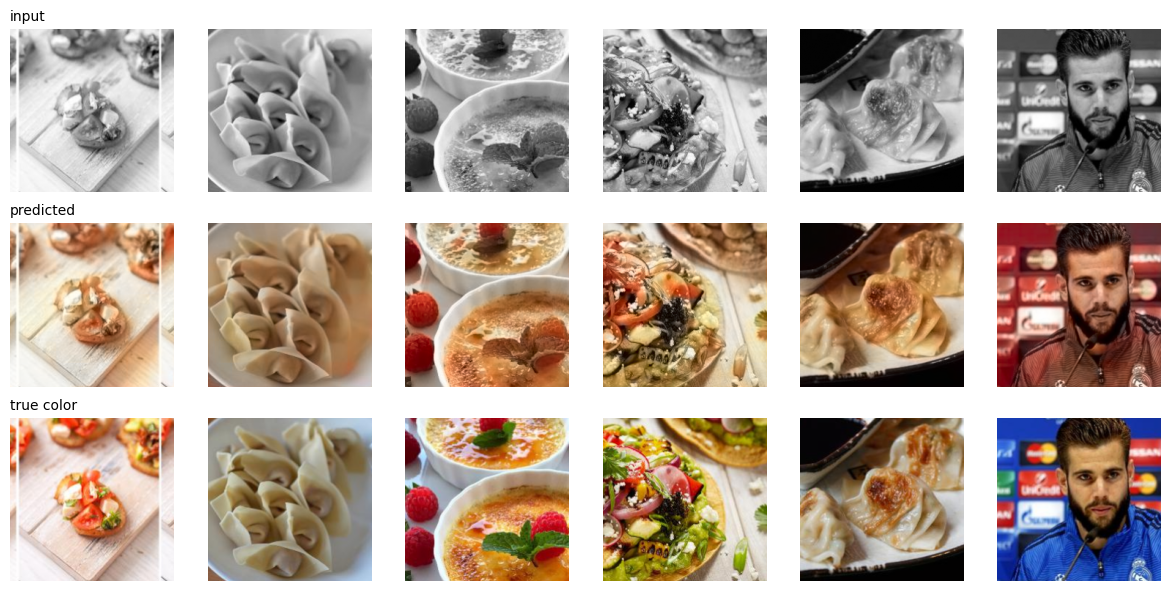

In [ ]:
def plot_colorization_examples(lit_model, dataloader, device, n=6):
    lit_model.eval().to(device)
    L_batch, ab_batch = next(iter(dataloader))
    L_batch = L_batch.to(device)

    with torch.no_grad():
        ab_pred = lit_model(L_batch).cpu()

    L_batch = L_batch.cpu()
    fig, axes = plt.subplots(3, n, figsize=(n * 2, 6))

    for i in range(n):
        gray = L_batch[i, 0].numpy()
        pred_rgb = lab_tensors_to_rgb(L_batch[i], ab_pred[i])
        true_rgb = lab_tensors_to_rgb(L_batch[i], ab_batch[i])

        axes[0, i].imshow(gray, cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(pred_rgb)
        axes[1, i].axis("off")
        axes[2, i].imshow(true_rgb)
        axes[2, i].axis("off")

    axes[0, 0].set_title("input", loc="left", fontsize=10)
    axes[1, 0].set_title("predicted", loc="left", fontsize=10)
    axes[2, 0].set_title("true color", loc="left", fontsize=10)
    plt.tight_layout()
    plt.show()


plot_colorization_examples(best_lit_model, val_loader, device)

## Extracting features with the frozen encoder

Pretraining is done, from here on the encoder weights never change again. To get a feature vector for classification we run each image through the encoder and then apply global average pooling on the resulting 512 by 7 by 7 map, collapsing it down to a single 512 number vector per image, the same pooling the supervised net applies right before its classifier layer.

In [ ]:
class GrayscaleLabeledDataset(Dataset):
    def __init__(self, df, img_size=224):
        self.df = df.reset_index(drop=True)
        self.transform = get_spatial_transform("val", img_size)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row["path"]).convert("RGB")
        except (OSError, IOError):
            return self.__getitem__((idx + 1) % len(self.df))

        img = self.transform(img)
        L, _ = image_to_lab_tensors(img)
        label = int(row["label"])
        return L, label

In [ ]:
feat_train_ds = GrayscaleLabeledDataset(dm.train_df, img_size=CFG["img_size"])
feat_test_ds = GrayscaleLabeledDataset(dm.test_df, img_size=CFG["img_size"])

feat_train_loader = DataLoader(feat_train_ds, batch_size=CFG["batch_size"], shuffle=False, num_workers=CFG["num_workers"])
feat_test_loader = DataLoader(feat_test_ds, batch_size=CFG["batch_size"], shuffle=False, num_workers=CFG["num_workers"])

encoder = best_lit_model.model.encoder

X_train, y_train = extract_features(encoder, feat_train_loader, device)
X_test, y_test = extract_features(encoder, feat_test_loader, device)

print("train features:", X_train.shape)
print("test features:", X_test.shape)

train features: (96326, 512)
test features: (11994, 512)


## Training the linear classifier on the extracted features

This is a linear classifier (Logistic regression) trained on top of frozen features, used to measure how good those features are without ever touching the encoder weights again.

In [ ]:
class_names = load_class_names(CFG["data_dir"])

linear_metrics, linear_clf = run_linear_probe(X_train, y_train, X_test, y_test, class_names=class_names)

linear_metrics["experiment"] = "ssl_colorization_linear_probe"
linear_metrics["config"] = CFG

accuracy : 0.2763
macro_precision : 0.2629
macro_recall : 0.2647
macro_f1 : 0.258
weighted_f1 : 0.2705
                                   precision    recall  f1-score   support

                        0 macaron       0.45      0.42      0.43        55
                        1 beignet       0.49      0.54      0.51        61
                        2 cruller       0.34      0.21      0.26        53
                    3 cockle_food       0.29      0.29      0.29        51
                         4 samosa       0.27      0.27      0.27        41
                       5 tiramisu       0.39      0.35      0.37        52
                        6 tostada       0.21      0.26      0.23        57
                       7 moussaka       0.21      0.17      0.19        54
                       8 dumpling       0.30      0.33      0.31        49
                        9 sashimi       0.41      0.46      0.43        46
                         10 knish       0.19      0.17      0.18       

Linear probe lands at 28% accuracy, 26% macro F1, well below what any of the supervised models managed, which tracks given the features never saw a single label during training.

Marble cake and chicken provencale fail here too, same as in every supervised run. Marble cake sits at precision 1.00 but recall 0.02, so the classifier basically only guesses it once and gets it right, but misses the other 48 times, probably picked up some narrow, distinctive corner of the embedding space from the handful of training examples. Chicken provencale is just bad across the board, 0.06/0.02/0.03, matching how badly it did in BaseNet.

## Nearest neighbor check

A second, cheap way to judge the same features: if the encoder learned something meaningful, images of the same food class should end up close to each other in feature space, and a nearest neighbor classifier should do reasonably well even without learning any decision boundary at all.

In [ ]:
knn_metrics, knn_clf = run_knn_probe(X_train, y_train, X_test, y_test, class_names=class_names, n_neighbors=5)

knn_metrics["experiment"] = "ssl_colorization_knn"
knn_metrics["config"] = CFG

accuracy : 0.0958
macro_precision : 0.1442
macro_recall : 0.0913
macro_f1 : 0.0909
weighted_f1 : 0.0953
                                   precision    recall  f1-score   support

                        0 macaron       0.12      0.16      0.14        55
                        1 beignet       0.17      0.41      0.25        61
                        2 cruller       0.07      0.19      0.10        53
                    3 cockle_food       0.07      0.29      0.12        51
                         4 samosa       0.05      0.27      0.08        41
                       5 tiramisu       0.05      0.12      0.07        52
                        6 tostada       0.07      0.28      0.11        57
                       7 moussaka       0.05      0.19      0.08        54
                       8 dumpling       0.06      0.16      0.08        49
                        9 sashimi       0.10      0.28      0.14        46
                         10 knish       0.03      0.10      0.05      

kNN comes in way worse than the linear probe, 9.6% vs 28% accuracy, which is actually a useful data point on its own. A linear classifier finding real signal while kNN barely does anything is exactly the kind of gap you'd expect if the raw 512-dim features aren't standardized before computing distances, a few high-variance dimensions could be dominating the neighbor search and drowning out whatever's actually discriminative.

Macro precision sitting well above macro recall (0.144 vs 0.091) fits the standardization claim too, when kNN does land on a class it's sometimes right, but it's mostly just not finding the correct neighbors at all, more scattered guessing than a real signal.

## Saving results

In [ ]:
save_metrics({"linear_probe": linear_metrics, "knn": knn_metrics}, LOG_DIR)

saved to /content/drive/MyDrive/Colab Notebooks/food-project/logs/ssl_colorization/metrics_summary.json


In [ ]:
# Unassign the runtime in order to not waste paid computing units
from google.colab import runtime
runtime.unassign()